<a href="https://colab.research.google.com/github/22f1000003/MLP-CODE/blob/main/w3_l2_demonstration_of_data_preprocessing_and_extraction_%2C_imputation%2C_scaling%2C_visualizing_feature_distribution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**data Preprocessing Techniques**

data preprocessing involves seberal transformations that are applied to the raw data to make it more amenable for learning it is carried out
before using it for model training or prediction
1. Data cleaning
   
   Data imputation

   Feature scaling

2. Feature transformation

   Polynomial Features
  
   Discretization

   handling categorical features

   custom transformations

     apply transformation to diverse features

     targetTransformed to diverse features

     TargetTransformedRegressor
3. Feature Selection

    Filter based feature selection

    wrapper based feature selection
4. Feature Extraction
  
    PCA

the transformations are applied in a specific order and the order can be specified via pipline. we need to apply different transformations based on the feature type. FeatureUnion helps us perform that task and combine multiple output from transformations into a single transformed feature matrix. we will also study as how to visulize this pipeline

  
  


**Importing basic libraries**
in this colab we are importing libraries as needed. however it is good practice to have all imports in one cell arranged in an alphabeticsl order this heps us weed out any duplecate imports and some such issues

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
sns.set_theme(style="whitegrid")

**1 . feature extraction**
**DictVectorizer**

many a times the data is oresent as list of **dictionary object **. ml algorithmas expect the data in matrix from with shape (n,m) where n is the number of samples and m is the number of feature
**Dictvectrizor converts a list of dictionary objects to feature matrix**



In [4]:
data = [{'age':4, 'hight':96.0},
        {'age':1, 'hight':73.5},
        {'age':3, 'hight':88.9},
        {'age':2, 'hight':81.2}]

there are 4 data samples with 2 features each
**let's make use DictVectorizer to convert the list of dictionary objects to a feature matrix**

In [5]:
from sklearn.feature_extraction import DictVectorizer
dv = DictVectorizer(sparse=False)
data_transformed = dv.fit_transform(data)
data_transformed


array([[ 4. , 96. ],
       [ 1. , 73.5],
       [ 3. , 88.9],
       [ 2. , 81.2]])

In [6]:
data_transformed.shape

(4, 2)

**Data Imputation**


*   many ml algo. need full feature matrix
*  



In [7]:
from sklearn.impute import SimpleImputer


missing value could be int float, str, np.nan or None. Default is np.nan
1. strategy mean median most frequent along each column
constant
 ** 1. add_indecator is a boolean parameter that when set to true return missing value indecator **
   

   mean and mode only for numerical ,,,, most_frequent and constant for string and numeric data

In [21]:
import pandas as pd

cols = ['age','sex','cp','trestbps','chol','fbs','restecg',
        'thalach','exang','oldpeak','slope','ca','thal','num']

heart_data = pd.read_csv(
    'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data',
    header=None,
    names=cols
)

step 1: check if the dataset contains missing values
 1. this can be checked via dataset description or by check number of nan  or np.null in the dataframe. however such a check can be performed only  for numerical features
 2. for non numerical features we can list their unique values and check if therer are values like ?.

In [26]:
heart_data.shape

(303, 14)

In [22]:
heart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    object 
 12  thal      303 non-null    object 
 13  num       303 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.3+ KB


**let's check if there any missing values in numerical columns . here we have checked it for all columns in dataframe**

In [23]:
(heart_data.isnull().sum())

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


there are two non numerical features: ca and thal
1. List their unique values

In [25]:
print('unique values in ca:', heart_data.ca.unique())
print('unique value in thal:', heart_data.thal.unique())

unique values in ca: ['0.0' '3.0' '2.0' '1.0' '?']
unique value in thal: ['6.0' '3.0' '7.0' '?']


both of them contain ? , which is missing values. lets count the number of missing values

In [31]:
print("missing value in ca:", heart_data.loc[heart_data.ca == '?', 'ca'].count())
print('missing value in thal', heart_data.loc[heart_data.thal == '?', 'thal'].count())

missing value in ca: 4
missing value in thal 2


**replace ? with nan**

In [32]:
heart_data.replace('?', np.nan, inplace=True)

**Step 3: Fill the missing values with sklearn missing values imputation utilities**
  
  
  here we use SimpleImputer with mean strategy


  we will try two variations-
    
    add_indicator = False: Default choice that only imputes missing values

In [33]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
heart_data_imputed = imputer.fit_transform(heart_data)
print(heart_data_imputed.shape)

(303, 14)


add_indicator = True: adds additional columns for each columns contains missing values. in our case this adds two collumns one for ca and other for thal. it indicates if the sample has a missing value

In [34]:
imputer = SimpleImputer(missing_values=np.nan, strategy='mean',add_indicator=True)
imputer = imputer.fit(heart_data)
heart_data_imputed_with_indicator = imputer.transform(heart_data)
print(heart_data_imputed_with_indicator.shape)

(303, 16)


**3. Feature scaling**
  
  feature scaling transforms feaure values such that all the features are on the same scale.


  when we use feature matrix with all feature on same scale, it provides us certain advantages as listed below

  1. **Enables faster convergence** in iterative optimization algorithms like gradient desent and its variants.
  2. the performance of ML algo. such as SVM , K-NN and K-means etc that computed euclidean distance among input samples gets impacted
  if the features are not scaled

  Tree based Ml algo. are not affected by feature-scaling. in other world, feauture scaling is not required for tree based ml algorithams

  **feature scaling can be performed with the following methods:**


1.   Standerdization
2.   Normalization
3.  MaxAbsScaler



**let's demonstrate feature scalling on real world datasets**

In [36]:
import pandas as pd

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/abalone/abalone.data"

columns = [
    "Sex", "Length", "Diameter", "Height",
    "Whole_weight", "Shucked_weight",
    "Viscera_weight", "Shell_weight", "Rings"
]

abalone_data = pd.read_csv(url, header=None, names=columns)

abalone_data.head()

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


**examine the dataset**

In [37]:
abalone_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   object 
 1   Length          4177 non-null   float64
 2   Diameter        4177 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole_weight    4177 non-null   float64
 5   Shucked_weight  4177 non-null   float64
 6   Viscera_weight  4177 non-null   float64
 7   Shell_weight    4177 non-null   float64
 8   Rings           4177 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 293.8+ KB


**1. [optional] convert non numerical attributes to numerical ones

1. in this dataset, sex is a non numeric column in this dataset. let's examine it and see if we can convert it to numeric

In [38]:
abalone_data.Sex.unique()

array(['M', 'F', 'I'], dtype=object)

convert  them in number

In [40]:
abalone_data = abalone_data.replace({'M':1, 'F':2, 'I':3})
abalone_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   int64  
 1   Length          4177 non-null   float64
 2   Diameter        4177 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole_weight    4177 non-null   float64
 5   Shucked_weight  4177 non-null   float64
 6   Viscera_weight  4177 non-null   float64
 7   Shell_weight    4177 non-null   float64
 8   Rings           4177 non-null   int64  
dtypes: float64(7), int64(2)
memory usage: 293.8 KB


**step 2: Seprate label from features**

In [41]:
y = abalone_data.pop("Rings")
abalone_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   int64  
 1   Length          4177 non-null   float64
 2   Diameter        4177 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole_weight    4177 non-null   float64
 5   Shucked_weight  4177 non-null   float64
 6   Viscera_weight  4177 non-null   float64
 7   Shell_weight    4177 non-null   float64
dtypes: float64(7), int64(1)
memory usage: 261.2 KB


**Examine feature scales**


Statical method

check the scale of different feature with describe() method of dataframe.

In [42]:
abalone_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Sex,4177.0,1.955470,0.827815,1.0000,1.0000,2.0000,3.000,3.0000
Length,4177.0,0.523992,0.120093,0.0750,0.4500,0.5450,0.615,0.8150
Diameter,4177.0,0.407881,0.099240,0.0550,0.3500,0.4250,0.480,0.6500
Height,4177.0,0.139516,0.041827,0.0000,0.1150,0.1400,0.165,1.1300
Whole_weight,4177.0,0.828742,0.490389,0.0020,0.4415,0.7995,1.153,2.8255
Shucked_weight,4177.0,0.359367,0.221963,0.0010,0.1860,0.3360,0.502,1.4880
Viscera_weight,4177.0,0.180594,0.109614,0.0005,0.0935,0.1710,0.253,0.7600
Shell_weight,4177.0,0.238831,0.139203,0.0015,0.1300,0.2340,0.329,1.0050


visualization of feature distribution

**Histogram**

**Kernel density estimation (KDE) plot**

**Box**

**Violin**

**Histogram**

/tmp/ipykernel_2036/3667226461.py:1: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=18, loc="upper right", frameon=True)


(array([[0.000e+00, 0.000e+00, 0.000e+00, 1.528e+03, 0.000e+00, 0.000e+00,
         1.307e+03, 0.000e+00, 0.000e+00, 1.342e+03],
        [2.140e+02, 2.660e+03, 1.303e+03, 0.000e+00, 0.000e+00, 0.000e+00,
         0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00],
        [6.210e+02, 3.537e+03, 1.900e+01, 0.000e+00, 0.000e+00, 0.000e+00,
         0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00],
        [4.175e+03, 1.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00,
         0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00],
        [6.610e+02, 8.750e+02, 8.730e+02, 8.360e+02, 5.420e+02, 2.520e+02,
         8.300e+01, 4.300e+01, 1.000e+01, 2.000e+00],
        [1.847e+03, 1.746e+03, 5.080e+02, 6.800e+01, 8.000e+00, 0.000e+00,
         0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00],
        [3.567e+03, 6.080e+02, 2.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
         0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00],
        [2.835e+03, 1.289e+03, 5.200e+01, 1.000e+00, 0.000e+00, 0.000e+00,
         0.000e+00, 0.

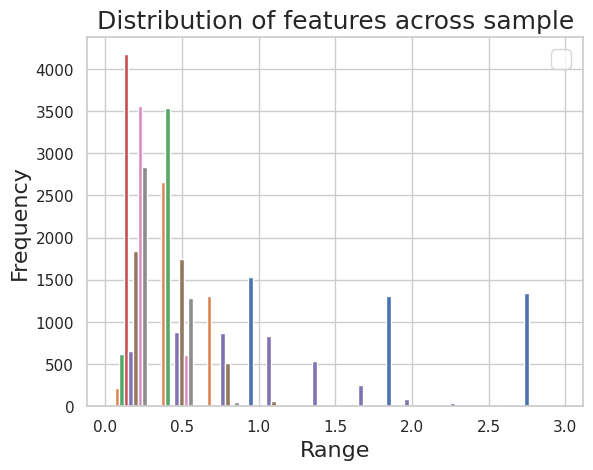

In [45]:
plt.legend(fontsize=18, loc="upper right", frameon=True)
plt.title("Distribution of features across sample", fontsize = 18)
plt.xlabel('Range',fontsize=16)
plt.ylabel('Frequency',fontsize=16)
plt.hist(abalone_data)

KDE plot

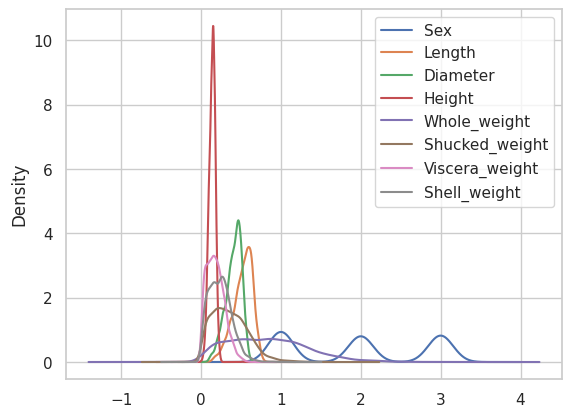

In [46]:
ax = abalone_data.plot.kde()

Box plot

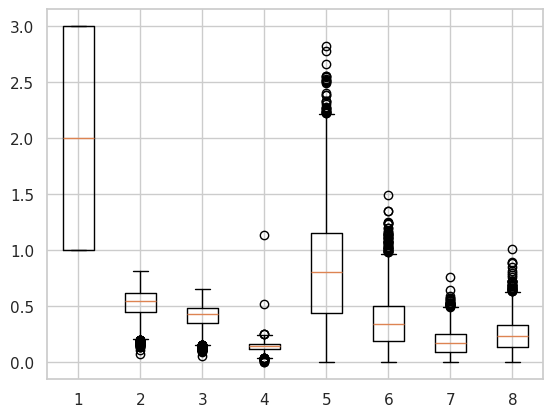

In [49]:
box_graph= plt.boxplot(abalone_data)

**Violine plot**

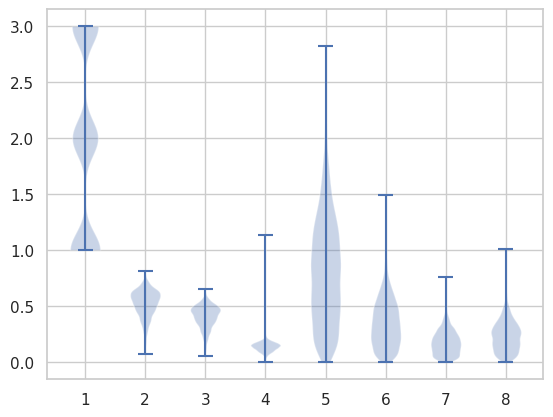

In [50]:
vp = plt.violinplot(abalone_data)

**Scaling**

Normalization

MaxAbsoluteScaler
[-1,1]

MinMaxScaler

[0,1]

In [55]:
import numpy as np
x = np.array([4,2,5,-2,-100]).reshape(-1,1)
print(x)

[[   4]
 [   2]
 [   5]
 [  -2]
 [-100]]


In [58]:
from sklearn.preprocessing import MaxAbsScaler
scaler = MaxAbsScaler()
x_new = scaler.fit_transform(x)
print(x_new)


[[ 0.04]
 [ 0.02]
 [ 0.05]
 [-0.02]
 [-1.  ]]


MinMaxScaler
range of it [0 to 1]

In [59]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
x_new = scaler.fit_transform(x)
print(x_new)

[[ 0.04]
 [ 0.02]
 [ 0.05]
 [-0.02]
 [-1.  ]]


let's look at the means and standerd deviation (SD) of each feature:

In [60]:
X_normalised.mean(axis=0)

NameError: name 'X_normalised' is not defined

standardize

In [63]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_standardized = scaler.fit_transform(x)
X_standardized[:5]

array([[ 0.54185681],
       [ 0.49304089],
       [ 0.56626478],
       [ 0.39540903],
       [-1.99657151]])